In [1]:
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.append(project_root)
warnings.filterwarnings('ignore')

In [63]:
# from kaggle.api.kaggle_api_extended import KaggleApi
# api = KaggleApi()
# api.authenticate()

# data_name = 'abhaypanchal/credit-fraud'

# api.dataset_download_files(dataset=data_name, path='../data', unzip=True)

In [2]:
df = pd.read_csv('../data/credit_fraud.csv')
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1


In [3]:
df.isna().sum()

age                       644
transaction_amount        647
account_balance           645
num_transactions_today    646
is_foreign_transaction    651
transaction_hour          643
prev_fraud_flag           646
merchant_distance_km      643
merchant_risk_score       644
is_fraud                    0
dtype: int64

In [4]:
df['is_fraud'].value_counts()

is_fraud
0    16740
1    15560
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold
num_cols = df.select_dtypes(include=['float', 'int']).columns
x_num = df[num_cols]

vt = VarianceThreshold(threshold=0.0)
x_num_vt = vt.fit_transform(x_num)

kept_cols = x_num.columns[vt.get_support()]
dropped_cols = x_num.columns[~vt.get_support()]

kept_cols, dropped_cols

(Index(['transaction_amount', 'account_balance', 'num_transactions_today',
        'is_foreign_transaction', 'transaction_hour', 'prev_fraud_flag',
        'merchant_distance_km', 'merchant_risk_score', 'is_fraud'],
       dtype='object'),
 Index([], dtype='object'))

In [6]:
from src.xgb_imputer_eval import clean_value_errors
df = clean_value_errors(df=df)

Cleaning: Menghapus format '_err' pada kolom age
Cleaning: Mengubah 1 baris usia negatif menjadi NaN
Cleaning: Mengubah 1 baris saldo placeholder menjadi NaN
Cleaning: Mengubah 1 baris jam tidak valid menjadi NaN


In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop('is_fraud', axis=1)
y = df['is_fraud']
xtrain, xval, ytrain, yval = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
xtrain, xtest, ytrain, ytest = train_test_split(xtrain, ytrain, test_size=0.2, stratify=ytrain, random_state=42)

In [8]:
xtrain.fillna(xtrain.median(numeric_only=True), inplace=True)
xval.fillna(xval.median(numeric_only=True), inplace=True)
xtest.fillna(xtest.median(numeric_only=True), inplace=True)

In [11]:
xtrain[xtrain.isna().any(axis=1)]

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score


In [9]:
from pathlib import Path
import yaml

def extract_metadata(X, y=None):
    """Simpan Informasi data"""
    meta = {
        "n_rows": int(X.shape[0]),
        "n_cols": int(X.shape[1]),
        "columns": list(X.columns),
        "dtypes": {col: str(dtype) for col, dtype in X.dtypes.items()},
    }

    if y is not None:
        meta["target"] = {
            "n_rows": int(y.shape[0]),
            "dtype": str(y.dtype),
            "unique_values": sorted(y.unique().tolist())
        }

    return meta

In [10]:
import joblib

ARTIFACT_DIR = Path("artifacts") / "preprocessing"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract metadata
metadata = {
    "xtrain": extract_metadata(xtrain, ytrain),
    "xval": extract_metadata(xval, yval),
    "xtest":  extract_metadata(xtest, ytest)
}

# Save YAML metadata
with open(ARTIFACT_DIR / "dataset_metadata.yaml", "w") as f:
    yaml.safe_dump(metadata, f, sort_keys=False)

# Save datasets
joblib.dump(xtrain, ARTIFACT_DIR / "xtrain.joblib")
joblib.dump(ytrain, ARTIFACT_DIR / "ytrain.joblib")

joblib.dump(xval, ARTIFACT_DIR / "xval.joblib")
joblib.dump(yval, ARTIFACT_DIR / "yval.joblib")

joblib.dump(xtest, ARTIFACT_DIR / "xtest.joblib")
joblib.dump(ytest, ARTIFACT_DIR / "ytest.joblib")

['artifacts\\preprocessing\\ytest.joblib']

In [15]:
xtrain.shape, ytrain.shape, xval.shape, yval.shape, xtest.shape, ytest.shape

((20672, 9), (20672,), (6460, 9), (6460,), (5168, 9), (5168,))

# EDA

In [11]:
data_train_eda = pd.concat([xtrain, ytrain], axis=1)
data_train_eda.shape

(20672, 10)

In [26]:
data_train_eda[num_cols].describe()

,age,transaction_amount,account_balance,num_transactions_today,transaction_hour,merchant_distance_km,merchant_risk_score
count,20672.00000,20672.000000,20672.000000,20672.000000,20672.000000,20672.000000,20672.000000
mean,46.02322,7450.702345,25060.640476,24.868566,11.481860,2500.395022,5.503522
std,16.33861,4292.073462,14205.724757,13.946975,6.858999,1429.078427,2.568242
min,18.00000,1.070000,7.210000,1.000000,0.000000,0.100000,1.000000
25%,32.00000,3756.052500,12940.422500,13.000000,6.000000,1273.200000,3.300000
50%,46.00000,7454.105000,25125.005000,25.000000,11.000000,2503.900000,5.500000
75%,60.00000,11127.415000,37261.630000,37.000000,17.000000,3717.825000,7.700000
max,74.00000,14999.710000,49998.900000,49.000000,23.000000,4999.800000,10.000000


ValueError: num must be an integer with 1 <= num <= 3, not 4

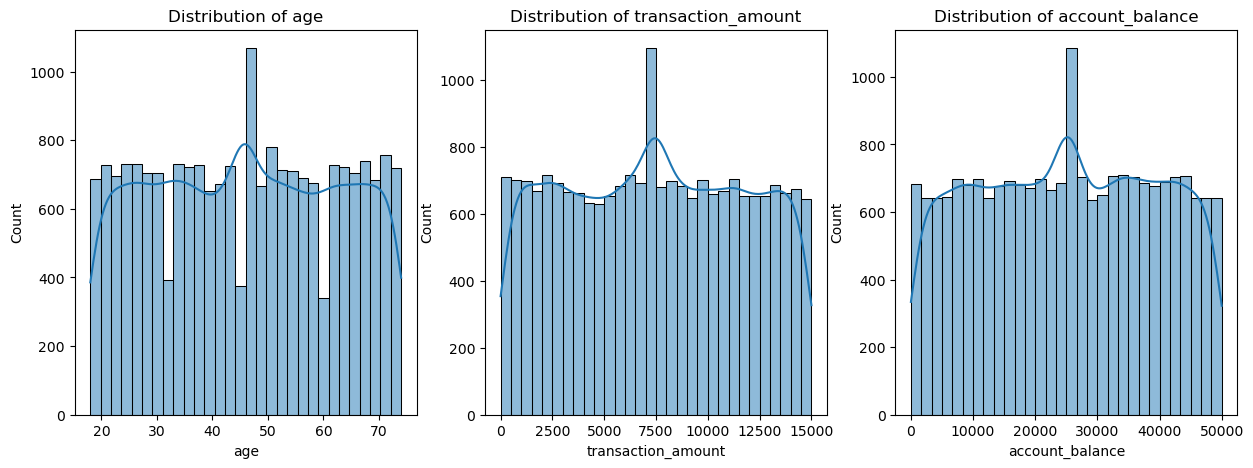

In [12]:
num_cols = [c for c in data_train_eda.columns if data_train_eda[c].nunique() > 3]
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(data_train_eda[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()


In [13]:
import scipy.stats as stats
import numpy as np

def best_fit_distribution(data, bins=50):
    """Pengecekan distribusi data menggunakan statistik"""
    data = data.dropna().values

    # histogram data
    y, x = np.histogram(data, bins=bins, density=True)
    x_mid = (x[:-1] + x[1:]) / 2

    distributions = [
        stats.norm,
        stats.lognorm,
        stats.expon,
        stats.gamma,
        stats.beta,
        stats.uniform
    ]

    best_dist = None
    best_params = None
    best_sse = np.inf

    for dist in distributions:
        try:
            params = dist.fit(data)
            pdf = dist.pdf(x_mid, *params)
            sse = np.sum((y - pdf) ** 2)

            if sse < best_sse:
                best_sse = sse
                best_dist = dist
                best_params = params
        except Exception:
            pass

    return best_dist.name, best_params, best_sse

In [14]:
# initialize
results = []

# jalankan fungsi
for col in num_cols:
    dist_name, params, sse = best_fit_distribution(data_train_eda[col])
    results.append({
        "feature": col,
        "best_distribution": dist_name,
        "sse": sse
    })

dist_df = pd.DataFrame(results)
dist_df

,feature,best_distribution,sse
0,age,uniform,2.084886e-03
1,transaction_amount,beta,4.743832e-09
2,account_balance,beta,4.057585e-10
3,num_transactions_today,uniform,9.584579e-04
4,transaction_hour,uniform,1.042051e-01
5,merchant_distance_km,beta,4.627451e-08
6,merchant_risk_score,uniform,4.309736e-02


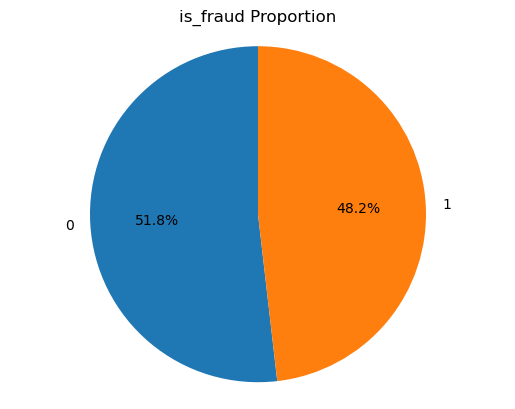

In [21]:
# hitung proporsi
is_fraud_counts = data_train_eda['is_fraud'].value_counts(normalize=True).sort_index()

# pie chart
plt.figure()
plt.pie(
    is_fraud_counts.values,
    labels=is_fraud_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('is_fraud Proportion')
plt.axis('equal')
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of Numerical Variables')

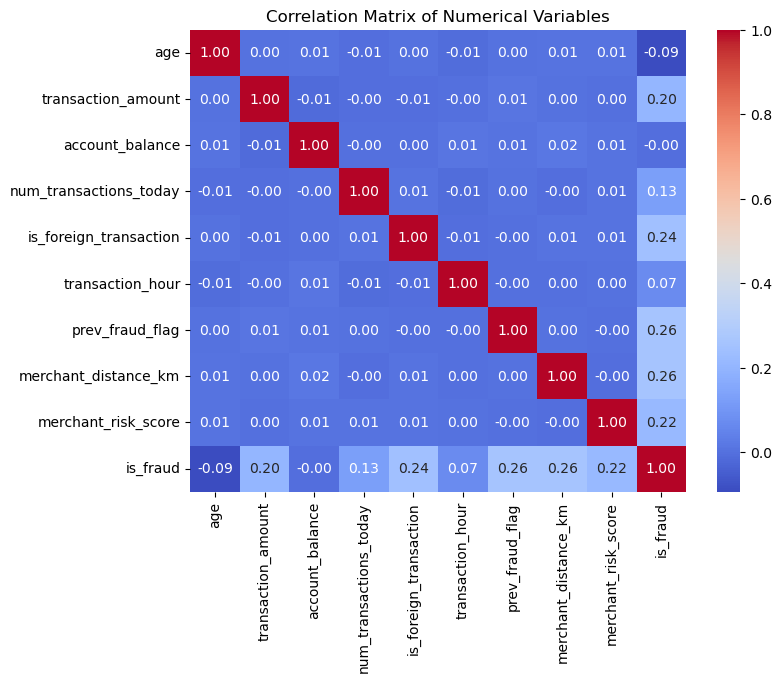

In [22]:
corr_matrix = data_train_eda.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')

# Multivariate

Text(0.5, 1.0, 'Correlation Heatmap')

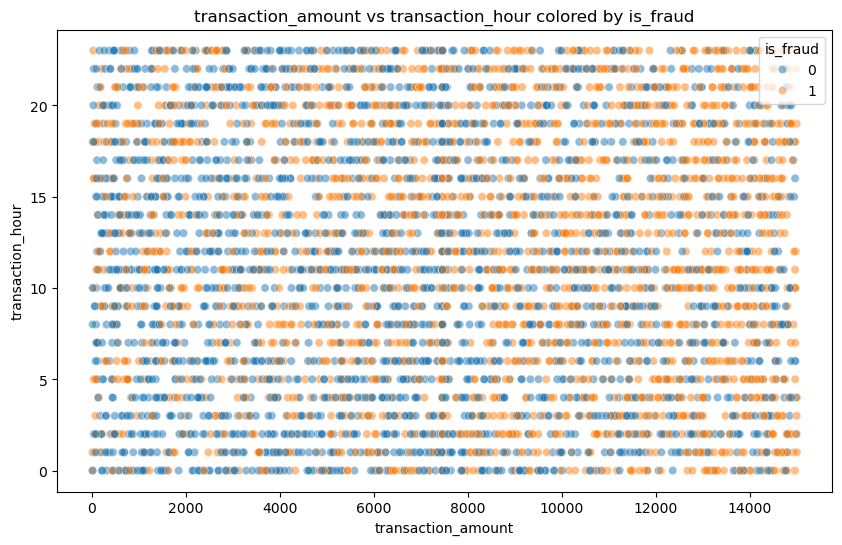

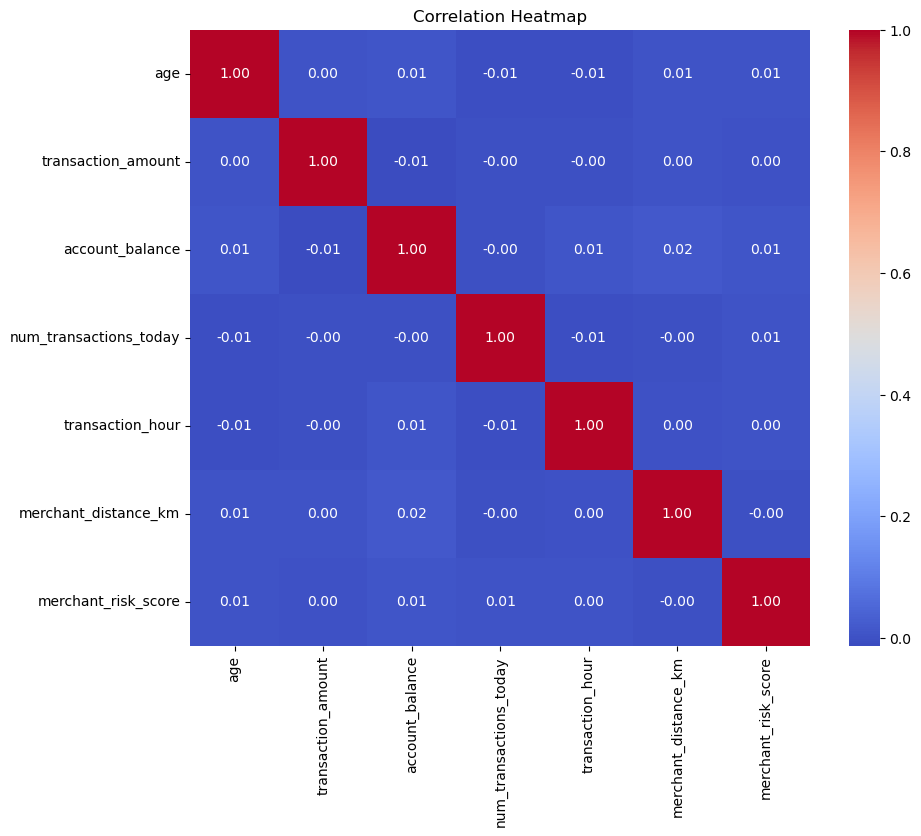

In [23]:
plt.figure(figsize=(10, 6))
df_sample = data_train_eda.sample(n=5000, random_state=42)
sns.scatterplot(data=df_sample, x='transaction_amount', y='transaction_hour', hue='is_fraud', alpha=0.5)
plt.title('transaction_amount vs transaction_hour colored by is_fraud')

plt.figure(figsize=(10, 8))
corr = data_train_eda[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

In [24]:
import math

def plot_scatter_num_vs_target(
    df,
    num_features,
    target_col='is_fraud',
    n_cols=3,
    jitter_std=0.03,
    figsize_per_row=4
):
    """
    Scatterplot bivariate: numeric continuous feature vs binary target.
    Digunakan untuk melihat lokasi titik fraud (sanity check, bukan inferensi final).
    """

    n_rows = math.ceil(len(num_features) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, figsize_per_row * n_rows)
    )
    axes = axes.flatten()

    for i, col in enumerate(num_features):
        y_jitter = df[target_col] + np.random.normal(
            0, jitter_std, size=len(df)
        )

        axes[i].scatter(
            df[col],
            y_jitter,
            alpha=0.3
        )

        axes[i].set_title(f'{col} vs {target_col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(f'{target_col} (jittered)')
        axes[i].set_yticks([0, 1])

    # hapus subplot kosong
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

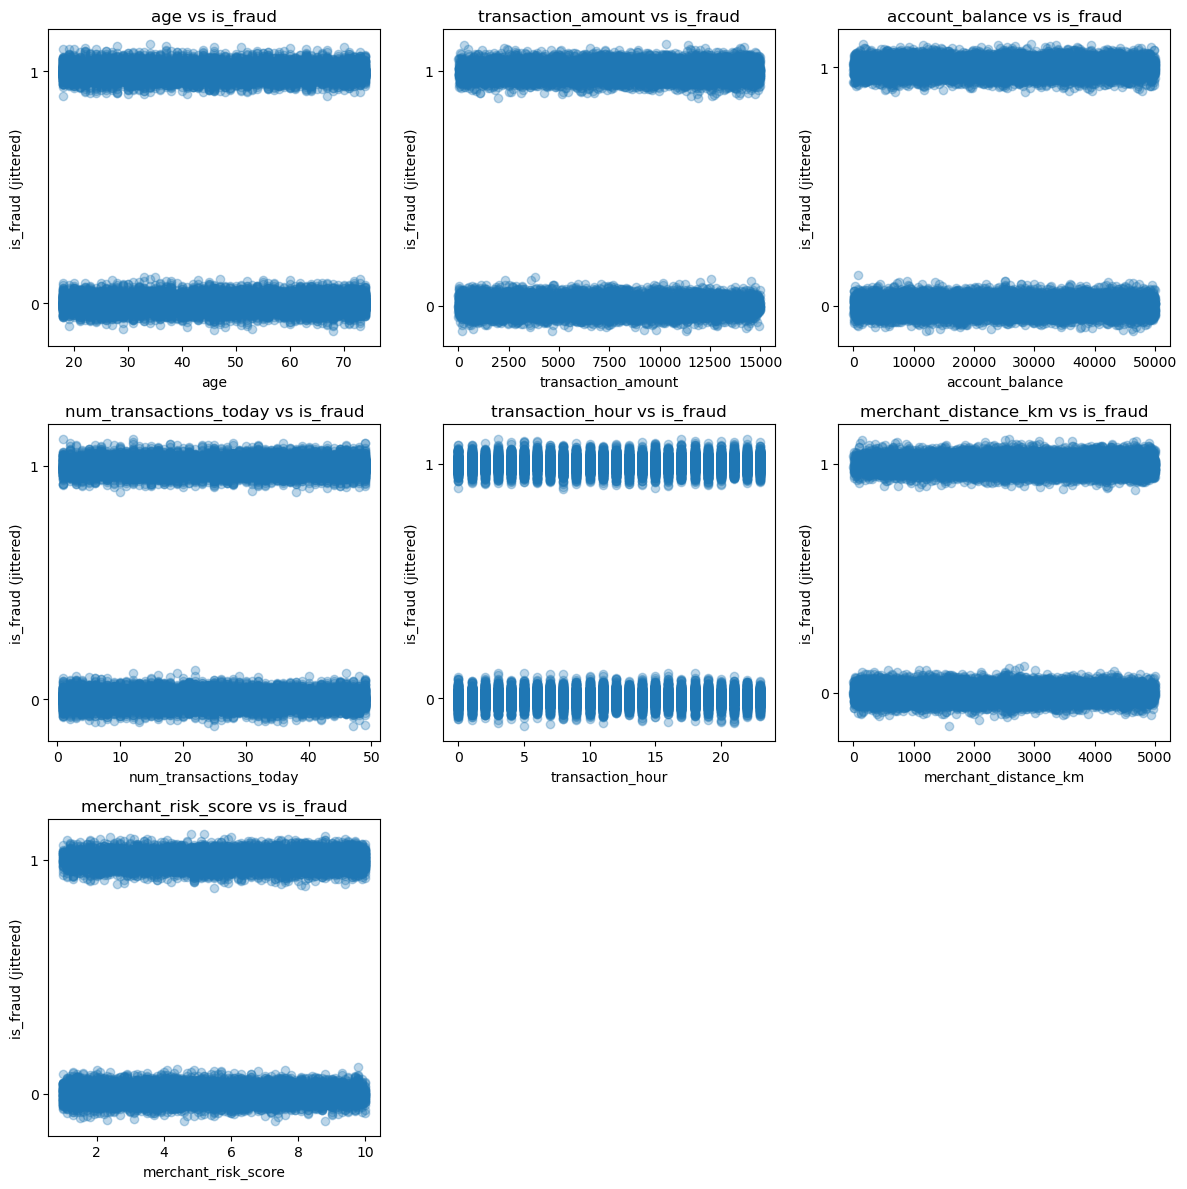

In [28]:
plot_scatter_num_vs_target(
    df=data_train_eda,
    num_features=num_cols,
    target_col='is_fraud'
)

In [33]:
import statsmodels.api as sm

# target
target_col = "is_fraud"

y = data_train_eda[target_col]
    
X = data_train_eda.drop(columns=[target_col])

# data numerik saja
X = X.select_dtypes(include=["number"])

# add intercept
X = sm.add_constant(X)

In [34]:
logit_model = sm.Logit(y, X)
result = logit_model.fit(maxiter=200)

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.502846
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:                20672
Model:                          Logit   Df Residuals:                    20662
Method:                           MLE   Df Model:                            9
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.2738
Time:                        23:16:47   Log-Likelihood:                -10395.
converged:                       True   LL-Null:                       -14315.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -4.4714      0.102    -43.809      0.000      -4.671      

In [35]:
def compute_vif(X):
    vif_data = []

    for col in X.columns:
        # X_j sebagai target
        y = X[col]

        # fitur lain sebagai predictor
        X_others = X.drop(columns=[col])
        X_others = sm.add_constant(X_others)

        # regresi linear
        model = sm.OLS(y, X_others).fit()
        r_squared = model.rsquared

        # hitung VIF
        vif = 1 / (1 - r_squared)

        vif_data.append({
            "feature": col,
            "R_squared": r_squared,
            "VIF": vif
        })

    return pd.DataFrame(vif_data)

In [36]:
X = data_train_eda.select_dtypes(include=["int64", "float64"]).copy()
X = X.dropna()

# jalankan function
vif_df = compute_vif(X)
vif_df.sort_values("VIF", ascending=False)

,feature,R_squared,VIF
9,is_fraud,0.309552,1.448335
7,merchant_distance_km,0.088483,1.097072
6,prev_fraud_flag,0.088269,1.096814
4,is_foreign_transaction,0.076873,1.083275
8,merchant_risk_score,0.063687,1.068019
1,transaction_amount,0.055889,1.059197
3,num_transactions_today,0.021545,1.022019
0,age,0.013771,1.013963
5,transaction_hour,0.007983,1.008047
2,account_balance,0.000797,1.000798


In [37]:
def auto_column_types(
    df,
    target_col=None,
    binary_unique_threshold=2,
    categorical_unique_ratio=0.05
):
    """
    Automatically categorize dataframe columns into:
    - numeric
    - binary
    - categorical

    Rules:
    - binary      : numeric or object with exactly 2 unique values
    - categorical : object OR numeric with low unique ratio
    - numeric     : numeric and not binary/categorical
    """

    numeric_cols = []
    binary_cols = []
    categorical_cols = []

    for col in df.columns:
        if col == target_col:
            continue

        nunique = df[col].nunique(dropna=True)
        unique_ratio = nunique / len(df)

        # Binary
        if nunique == binary_unique_threshold:
            binary_cols.append(col)

        # Numeric
        elif pd.api.types.is_numeric_dtype(df[col]) and unique_ratio > categorical_unique_ratio:
            numeric_cols.append(col)

        # Categorical
        else:
            categorical_cols.append(col)

    return {
        "numeric": numeric_cols,
        "binary": binary_cols,
        "categorical": categorical_cols
    }


In [38]:
col_types = auto_column_types(data_train_eda, target_col="is_fraud")

numeric_cols = col_types["numeric"]
binary_cols = col_types["binary"]
categorical_cols = col_types["categorical"]

print("Numeric:", numeric_cols)
print("Binary:", binary_cols)
print("Categorical:", categorical_cols)


Numeric: ['transaction_amount', 'account_balance', 'merchant_distance_km']
Binary: ['is_foreign_transaction', 'prev_fraud_flag']
Categorical: ['age', 'num_transactions_today', 'transaction_hour', 'merchant_risk_score']


In [40]:
from scipy.stats import pointbiserialr

def numeric_vs_binary(
    df,
    numeric_cols,
    target_col,
    alpha=0.05
):
    """
    Point-Biserial correlation for numeric vs binary target

    Adds:
    - significant (p < alpha)
    - effect_size (weak / moderate / strong)
    - direction (higher in class 1 / class 0)
    """

    rows = []

    for col in numeric_cols:
        corr, p = pointbiserialr(df[target_col], df[col])

        # significance
        significant = p < alpha

        # effect size interpretation
        abs_corr = abs(corr)
        if abs_corr < 0.1:
            effect = "very weak"
        elif abs_corr < 0.3:
            effect = "weak"
        elif abs_corr < 0.5:
            effect = "moderate"
        else:
            effect = "strong"

        # direction
        if corr > 0:
            direction = "higher when target = 1"
        elif corr < 0:
            direction = "higher when target = 0"
        else:
            direction = "no difference"

        rows.append({
            "feature": col,
            "correlation": corr,
            "abs_corr": abs_corr,
            "p_value": p,
            "significant": significant,
            "effect_size": effect,
            "direction": direction
        })

    return (
        pd.DataFrame(rows)
        .sort_values("abs_corr", ascending=False)
        .reset_index(drop=True)
    )

In [42]:
numeric_vs_binary(data_train_eda, numeric_cols, 'is_fraud')

,feature,correlation,abs_corr,p_value,significant,effect_size,direction
0,merchant_distance_km,0.259432,0.259432,3.886049e-315,True,weak,higher when target = 1
1,transaction_amount,0.203370,0.203370,7.053738e-192,True,weak,higher when target = 1
2,account_balance,-0.004303,0.004303,5.361391e-01,False,very weak,higher when target = 0


In [43]:
from scipy.stats import chi2_contingency

def binary_vs_binary(
    df,
    binary_cols,
    target_col,
    alpha=0.05
):
    """
    Binary (categorical) vs Binary target analysis
    Uses Chi-Square test + Cramér's V

    Adds:
    - significant (p < alpha)
    - effect_size interpretation
    - interpretation text
    """

    rows = []

    for col in binary_cols:
        if col == target_col:
            continue

        ct = pd.crosstab(df[col], df[target_col])

        # chi-square test
        chi2, p_value, _, _ = chi2_contingency(ct)

        # cramér's v
        n = ct.sum().sum()
        v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

        # significance
        significant = p_value < alpha

        # effect size interpretation
        if v < 0.1:
            effect = "very weak"
        elif v < 0.3:
            effect = "weak"
        elif v < 0.5:
            effect = "moderate"
        else:
            effect = "strong"

        # simple interpretation
        if not significant:
            insight = "no statistically significant association"
        else:
            insight = f"statistically significant ({effect} association)"

        rows.append({
            "feature": col,
            "cramers_v": v,
            "p_value": p_value,
            "significant": significant,
            "effect_size": effect,
            "interpretation": insight
        })

    return (
        pd.DataFrame(rows)
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )


In [44]:
binary_vs_binary(data_train_eda, binary_cols, 'is_fraud')

,feature,cramers_v,p_value,significant,effect_size,interpretation
0,prev_fraud_flag,0.259816,2.050781e-305,True,weak,statistically significant (weak association)
1,is_foreign_transaction,0.241138,2.218164e-263,True,weak,statistically significant (weak association)


# Feature Engineering

In [15]:
from src.feature_engineer import FraudFeatureEngineer
fe = FraudFeatureEngineer()

xtrain_fe = fe.fit_transform(xtrain)
xval_fe = fe.transform(xval)
xtest_fe = fe.transform(xtest)

In [31]:
data_train_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20672 entries, 15913 to 12009
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     20672 non-null  float64
 1   transaction_amount      20672 non-null  float64
 2   account_balance         20672 non-null  float64
 3   num_transactions_today  20672 non-null  float64
 4   is_foreign_transaction  20672 non-null  float64
 5   transaction_hour        20672 non-null  float64
 6   prev_fraud_flag         20672 non-null  float64
 7   merchant_distance_km    20672 non-null  float64
 8   merchant_risk_score     20672 non-null  float64
 9   tx_balance_ratio        20672 non-null  float64
 10  dist_risk_score         20672 non-null  float64
 11  sin_hour                20672 non-null  float64
 12  cos_hour                20672 non-null  float64
 13  is_late_night           20672 non-null  int64  
 14  is_fraud                20672 non-null 

In [70]:
from src.xgb_imputer_eval import clean_value_errors, apply_imputation, evaluate_imputation, get_all_imputation_configs

In [18]:
from src.fraud_training_pipeline import build_fraud_pipeline
from sklearn.metrics import classification_report, f1_score
pipeline = build_fraud_pipeline()   
        
# Training
print("\nStep 1: Training Full Pipeline (Cleaning + Imputation + Scaling + Model)...")
pipeline.fit(xtrain_fe, ytrain)

# Evaluation on Validation Set
print("\nStep 2: Evaluating on Validation Set (Missing values filled automatically)...")
yval_pred = pipeline.predict(xval_fe)
print("\nValidation Results:")
print(classification_report(yval, yval_pred))
        
# Evaluation on Test Set
print("\nStep 3: Final Testing on Test Set...")
ytest_pred = pipeline.predict(xtest_fe)
print("\nTest Results:")
print(classification_report(ytest, ytest_pred))
        
f1 = f1_score(ytest, ytest_pred)
print(f"\nFinal Test F1-Score: {f1:.4f}")
        
# Pipeline check
print("\nPipeline check: All missing values handled? ", end="")
xtest_processed = pipeline.named_steps['imputer'].transform(pipeline.named_steps['cleaner'].transform(xtest))
print(not xtest_processed.isnull().any().any())



Step 1: Training Full Pipeline (Cleaning + Imputation + Scaling + Model)...

Step 2: Evaluating on Validation Set (Missing values filled automatically)...

Validation Results:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      3348
           1       0.73      0.70      0.71      3112

    accuracy                           0.73      6460
   macro avg       0.73      0.73      0.73      6460
weighted avg       0.73      0.73      0.73      6460


Step 3: Final Testing on Test Set...

Test Results:
              precision    recall  f1-score   support

           0       0.73      0.77      0.75      2678
           1       0.73      0.69      0.71      2490

    accuracy                           0.73      5168
   macro avg       0.73      0.73      0.73      5168
weighted avg       0.73      0.73      0.73      5168


Final Test F1-Score: 0.7099

Pipeline check: All missing values handled? True


In [20]:
from sklearn.metrics import confusion_matrix
y_pred_proba = pipeline.predict_proba(xtest_fe)[:, 1]

new_threeslhd = 0.3

y_pred_tune = (y_pred_proba >= new_threeslhd).astype(int)
print(f'report dengan new thrshld {new_threeslhd}')
print(classification_report(ytest, y_pred_tune))

print('confusion_matrix')
print(confusion_matrix(ytest, y_pred_tune))

report dengan new thrshld 0.3
              precision    recall  f1-score   support

           0       0.80      0.57      0.66      2678
           1       0.65      0.85      0.73      2490

    accuracy                           0.70      5168
   macro avg       0.72      0.71      0.70      5168
weighted avg       0.73      0.70      0.70      5168

confusion_matrix
[[1515 1163]
 [ 376 2114]]


In [88]:
from sklearn.metrics import recall_score, precision_score, f1_score, fbeta_score, roc_auc_score

print(f"roc auc: {roc_auc_score(ytest, y_pred_tune)}")
print(f"recall: {recall_score(ytest, y_pred_tune)}")
print(f"precision: {precision_score(ytest, y_pred_tune)}")
print(f"f1: {f1_score(ytest, y_pred_tune)}")
print(f"fbeta: {fbeta_score(ytest, y_pred_tune, beta=2)}")

roc auc: 0.7047268986326186
recall: 0.8538152610441767
precision: 0.6411338962605548
f1: 0.7323458491215984
fbeta: 0.8006929798131968
